In [1]:
import pandas as pd
import pickle
import ast
import matplotlib.pyplot as plt
import seaborn as sns
import json
import numpy as np
from scipy.stats import chi2
import textwrap

In [2]:
DISEASE = input("Disease: ")
DISEASE_FOLDER = f"../output/{DISEASE}/"
RESULT_FOLDER = DISEASE_FOLDER + "leiden_results"
DGIDB_DIRECTORY = f"../../Gen_Hypergraph/output/DGIDB_{DISEASE}/"

# Comm DGIDB genes count

In [3]:
def DGIDB_count(c,DGIDB_genes_ncbi):
    return set(c) & set(DGIDB_genes_ncbi)

In [4]:
def DGIDB_count(c,DGIDB_genes_ncbi):
    return set(c) & set(DGIDB_genes_ncbi)

In [5]:
with open(f"{RESULT_FOLDER}/result_communities_ncbi_selected.pkl", "rb") as f:
    communities_ncbi_selected = pickle.load(f)
with open(f"{RESULT_FOLDER}/result_communities_ncbi.pkl", "rb") as f:
    communities_ncbi = pickle.load(f)
with open(DGIDB_DIRECTORY + f"gene_to_index.json", "r") as file:
    DGIDB_gene_to_index = json.load(file)
DGIDB_genes = set(DGIDB_gene_to_index.keys())

In [6]:
comm_dgidb_gene_count = {}
for i in range(len(communities_ncbi_selected)):
    dgidb_genes_set = DGIDB_count(communities_ncbi[i],DGIDB_genes)
    print(i,len(dgidb_genes_set), dgidb_genes_set)
    print(len(communities_ncbi[i]))
    comm_dgidb_gene_count[i] = len(dgidb_genes_set)
    
with open(f"../output/{DISEASE}/comm_dgidb_gene_count.json","w") as f:
    json.dump(comm_dgidb_gene_count,f)    

0 16 {'7917', '262', '5538', '327', '27068', '79718', '3308', '5428', '6606', '22908', '10013', '3305', '8314', '10213', '4967', '440275'}
4080
1 21 {'214', '339745', '406', '2908', '3628', '4781', '3303', '2035', '79885', '9734', '7082', '28951', '2289', '23043', '7494', '4907', '8837', '6311', '4780', '490', '7915'}
3322
2 32 {'3553', '100507436', '7066', '718', '1636', '1012', '3558', '265', '4353', '7133', '3123', '2', '3552', '2658', '1277', '3953', '928', '7124', '50852', '3115', '3107', '3106', '8792', '64388', '3105', '5617', '6347', '2670', '3119', '4005', '10536', '355'}
2931
3 70 {'1815', '3354', '6329', '3356', '151', '6335', '6531', '2561', '152', '152330', '40', '2740', '6530', '5144', '887', '4922', '1812', '2566', '22999', '2555', '1816', '778', '6336', '24', '3357', '3778', '3760', '4160', '2668', '3352', '155', '267012', '3757', '1813', '255239', '3351', '51738', '5460', '150', '2895', '3358', '360158', '8912', '1814', '776', '238', '2917', '1131', '3350', '2562', '25

# important terms processing

In [7]:
with open(f"{RESULT_FOLDER}/result_communities_selected.pkl", "rb") as f:
    communities_selected = pickle.load(f)

In [8]:
important_terms = pd.read_csv(DISEASE_FOLDER + "important_terms.csv")

In [9]:
important_terms = important_terms.sort_values(
    by=["Community Index", "Adjusted P-value"],
    ascending=[True, True]
).reset_index(drop=True)

In [10]:
important_terms

,Community Index,Community Size,Term,Overlap,Adjusted P-value,Category,Gene_set,P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes,Overlap (value)
0,0,1097,RNA Binding (GO:0003723),351/1411,6.843116e-143,['binding'],GO_Molecular_Function_2023,1.677234e-145,0.0,0.0,7.920093,2640.224035,EIF4A1;TCERG1;RTCA;RRP1;PPAN;HNRNPU;GPATCH4;HN...,0.248760
1,0,1097,"mRNA Splicing, Via Spliceosome (GO:0000398)",123/211,2.514856e-96,['cellular process'],GO_Biological_Process_2023,1.179023e-99,0.0,0.0,27.000245,6150.419243,GEMIN2;HNRNPU;HNRNPR;CASC3;CWC27;PNN;SNRPD2;SN...,0.582938
2,0,1097,"RNA Splicing, Via Transesterification Reaction...",109/180,9.145320e-88,['cellular process'],GO_Biological_Process_2023,8.575078e-91,0.0,0.0,29.262246,6068.591273,HNRNPU;HNRNPR;CASC3;CWC27;PNN;SNRPD2;RBMX2;SNR...,0.605556
3,0,1097,mRNA Processing (GO:0006397),117/214,2.107879e-87,['cellular process'],GO_Biological_Process_2023,2.964668e-90,0.0,0.0,23.146455,4771.546614,TCERG1;GEMIN2;HNRNPU;HNRNPR;CASC3;CWC27;PNN;SN...,0.546729
4,0,1097,mRNA Splicing R-HSA-72172,109/189,7.202324e-85,['Metabolism of RNA'],Reactome_2022,1.640620e-87,0.0,0.0,25.957831,5187.149015,HNRNPU;HNRNPR;CASC3;CWC27;CCAR1;SNRPD2;MAGOH;M...,0.576720
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3109,11,132,Epidermal Cell Differentiation (GO:0009913),11/54,6.623089e-13,"['developmental process', 'cellular process']",GO_Biological_Process_2023,5.094684e-14,0.0,0.0,41.913319,1282.882613,TGM1;SPRR2F;SPRR3;SPRR2G;CDSN;KRT16;LORICRIN;K...,0.203704
3110,11,132,Peptide Cross-Linking (GO:0018149),9/27,8.824325e-13,['cellular process'],GO_Biological_Process_2023,7.636435e-14,0.0,0.0,80.691057,2437.133003,SPRR2E;TGM1;KRT2;KRT1;LORICRIN;KRT10;TGM5;IVL;...,0.333333
3111,11,132,Desmosome (GO:0030057),6/17,4.726332e-09,['cellular anatomical structure'],GO_Cellular_Component_2023,8.593331e-10,0.0,0.0,85.961039,1794.425035,CDSN;KAZN;DSG1;DSG3;DSG4;DSC1,0.352941
3112,11,132,Intermediate Filament Cytoskeleton (GO:0045111),9/81,1.386349e-08,['cellular anatomical structure'],GO_Cellular_Component_2023,3.150793e-09,0.0,0.0,20.117886,393.819930,KRT80;KRT3;KRT16;KRT2;KRT36;KRT10;KRT20;KRT75;...,0.111111


# Community Category df

In [11]:
df = important_terms

# ---------------------------------------------------
# 1. Parse Category column (stringified list) -> list
# ---------------------------------------------------
df["Category"] = df["Category"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

# ---------------------------------------------------
# 2. Explode: one category per row
# ---------------------------------------------------
df_exp = df.explode("Category").reset_index(drop=True)

# ---------------------------------------------------
# 3. Parse Overlap "a/b" into numerator and denominator
# ---------------------------------------------------
def parse_overlap(s):
    try:
        a, b = s.split("/")
        return int(a), int(b)
    except Exception:
        return 0, 0

overlap_nums = []
overlap_dens = []

for s in df_exp["Overlap"]:
    a, b = parse_overlap(s)
    overlap_nums.append(a)
    overlap_dens.append(b)

df_exp["Overlap_num"] = overlap_nums
df_exp["Overlap_den"] = overlap_dens

# ---------------------------------------------------
# 4. Total number of terms per community
# ---------------------------------------------------
total_terms = (
    df_exp.groupby("Community Index")["Term"]
          .nunique()
)

# ---------------------------------------------------
# 5. Aggregate per (Community Index, Category)
#    - count = # of distinct terms
#    - Gross Overlap = (sum a_i) / (sum b_i)
# ---------------------------------------------------
# ---------------------------------------------------
# 5. Aggregate per (Community Index, Category)
#    - count = # of distinct terms
#    - Gross Overlap = (sum a_i) / (sum b_i)
#    - fisher_p = Fisher-combined p-value over terms in that category
# ---------------------------------------------------
def fisher_method(pvals):
    p = pd.Series(pvals).dropna().astype(float)
    if len(p) == 0:
        return np.nan

    # avoid log(0)
    p = p.clip(lower=1e-300)

    stat = -2.0 * np.sum(np.log(p))
    df = 2 * len(p)
    return float(chi2.sf(stat, df))

agg = (
    df_exp.groupby(["Community Index", "Category"])
    .agg(
        count=("Term", "nunique"),
        sum_a=("Overlap_num", "sum"),
        sum_b=("Overlap_den", "sum"),
        fisher_p=("Adjusted P-value", fisher_method),  # <-- change column name if needed
    )
    .reset_index()
)

agg["Gross Overlap"] = agg["sum_a"] / agg["sum_b"]

# ---------------------------------------------------
# 6. Add total_terms_in_comm and frac_of_comm
# ---------------------------------------------------
agg["total_terms_in_comm"] = agg["Community Index"].map(total_terms)
agg["frac_of_comm"] = agg["count"] / agg["total_terms_in_comm"]

# ---------------------------------------------------
# 7. Final output df
# ---------------------------------------------------
community_categories = agg[[
    "Community Index",
    "Category",
    "count",
    "Gross Overlap",
    "fisher_p",
    "total_terms_in_comm",
    "frac_of_comm",
]]


community_categories = community_categories.sort_values(
    by=["Community Index", "count"],
    ascending=[True, False]
).reset_index(drop=True)

community_categories


,Community Index,Category,count,Gross Overlap,fisher_p,total_terms_in_comm,frac_of_comm
0,0,cellular process,50,0.301479,0.000000e+00,149,0.335570
1,0,biological regulation,24,0.303030,8.133650e-127,149,0.161074
2,0,protein-containing complex,19,0.622896,4.904073e-269,149,0.127517
3,0,Metabolism of RNA,13,0.351643,0.000000e+00,149,0.087248
4,0,binding,12,0.249362,2.425345e-208,149,0.080537
...,...,...,...,...,...,...,...
237,11,cellular process,6,0.197183,2.752539e-144,20,0.300000
238,11,cellular anatomical structure,5,0.336032,3.871064e-116,20,0.250000
239,11,Developmental Biology,3,0.212546,0.000000e+00,20,0.150000
240,11,Endocrine system,1,0.138686,6.722506e-20,20,0.050000


In [12]:
community_categories["fisher_score"] = -np.log10(
    community_categories["fisher_p"].clip(lower=1e-300)
)

mn = community_categories["fisher_score"].min()
mx = community_categories["fisher_score"].max()

community_categories["fisher_norm"] = (community_categories["fisher_score"] - mn) / (mx - mn)

def safe_z(x):
    mu = x.mean()
    sd = x.std(ddof=0)
    if sd == 0 or np.isnan(sd):
        return pd.Series(0.0, index=x.index)   # or return x*0
    return (x - mu) / sd

community_categories["fisher_z"] = (
    community_categories
    .groupby("Community Index")["fisher_score"]
    .transform(safe_z)
)




In [13]:
community_categories

,Community Index,Category,count,Gross Overlap,fisher_p,total_terms_in_comm,frac_of_comm,fisher_score,fisher_norm,fisher_z
0,0,cellular process,50,0.301479,0.000000e+00,149,0.335570,300.000000,1.000000,1.994148
1,0,biological regulation,24,0.303030,8.133650e-127,149,0.161074,126.089715,0.414260,0.361272
2,0,protein-containing complex,19,0.622896,4.904073e-269,149,0.127517,268.309443,0.893264,1.696599
3,0,Metabolism of RNA,13,0.351643,0.000000e+00,149,0.087248,300.000000,1.000000,1.994148
4,0,binding,12,0.249362,2.425345e-208,149,0.080537,207.615226,0.688843,1.126730
...,...,...,...,...,...,...,...,...,...,...
237,11,cellular process,6,0.197183,2.752539e-144,20,0.300000,143.560267,0.473102,0.294475
238,11,cellular anatomical structure,5,0.336032,3.871064e-116,20,0.250000,115.412170,0.378298,-0.004972
239,11,Developmental Biology,3,0.212546,0.000000e+00,20,0.150000,300.000000,1.000000,1.958727
240,11,Endocrine system,1,0.138686,6.722506e-20,20,0.050000,19.172469,0.054157,-1.028798


## filtering top 5 categories

In [14]:
# community_categories_filtered = (
#     community_categories.sort_values(["Community Index", "count"], ascending=[True, False])
#           .groupby("Community Index")
#           .head(5)
#           .reset_index(drop=True)
# )

In [15]:
# community_categories_filtered

In [16]:
# from reportlab.lib.pagesizes import letter, landscape
# from reportlab.platypus import SimpleDocTemplate, Table, TableStyle
# from reportlab.lib import colors

# def df_to_pdf(df, filename="output.pdf"):
#     pdf = SimpleDocTemplate(
#         filename,
#         pagesize=landscape(letter)
#     )

#     # Convert DF to 2D list
#     data = [df.columns.tolist()] + df.values.tolist()

#     # Create table
#     table = Table(data)

#     # Styling
#     style = TableStyle([
#         ("BACKGROUND", (0,0), (-1,0), colors.lightgrey),
#         ("TEXTCOLOR", (0,0), (-1,0), colors.black),
#         ("ALIGN", (0,0), (-1,-1), "CENTER"),
#         ("FONTNAME", (0,0), (-1,0), "Helvetica-Bold"),
#         ("FONTSIZE", (0,0), (-1,-1), 8),
#         ("BOTTOMPADDING", (0,0), (-1,0), 8),
#         ("GRID", (0,0), (-1,-1), 0.25, colors.black),
#     ])
#     table.setStyle(style)

#     elements = [table]
#     pdf.build(elements)
#     print(f"PDF saved to {filename}")


## output to pdf

In [17]:
# community_categories_filtered

In [18]:
# df_to_pdf(community_categories_filtered, f"../../Graphs/{DISEASE}/community_categories_filtered.pdf")

# Community Count Dict

In [19]:
category_count_by_comm = {}

for _, row in community_categories.iterrows():
    comm = row["Community Index"]
    cat = row["Category"]
    count = row["count"]
    gross = row["Gross Overlap"]

    if comm not in category_count_by_comm:
        category_count_by_comm[comm] = {}

    # insertion happens in sorted order because community_categories is sorted
    category_count_by_comm[comm][cat] = (count, gross)


In [20]:
for i in range(len(communities_selected)):
    if i not in category_count_by_comm.keys():
        category_count_by_comm[i] = {}

In [21]:
category_count_by_comm

{0: {'cellular process': (50, 0.3014794082367053),
  'biological regulation': (24, 0.30303030303030304),
  'protein-containing complex': (19, 0.622895622895623),
  'Metabolism of RNA': (13, 0.35164340387212967),
  'binding': (12, 0.24936170212765957),
  'localization': (9, 0.3341288782816229),
  'catalytic activity': (8, 0.14799281006590773),
  'cellular anatomical structure': (8, 0.1294225963435486),
  'Immune System': (2, 0.1708029197080292),
  'Metabolism of proteins': (2, 0.17228464419475656),
  'Translation': (2, 0.21844660194174756),
  'Disease': (1, 0.23404255319148937),
  'Folding, sorting and degradation': (1, 0.20714285714285716),
  'Gene expression (Transcription)': (1, 0.43283582089552236),
  'Protein localization': (1, 0.2153846153846154),
  'Transcription': (1, 0.56),
  'biological process involved in interspecies interaction between organisms': (1,
   0.7142857142857143),
  'viral process': (1, 0.7142857142857143)},
 1: {'cellular process': (3, 0.18095238095238095),
  'c

In [22]:
with open(f"{DISEASE_FOLDER}/category_count_by_comm.pkl", "wb") as f:
    pickle.dump(category_count_by_comm, f)

# Heatmap with filtered categories

In [23]:
# counts = important_terms["Community Index"].value_counts()
# top_idx = counts.idxmax()
# top_idx

In [24]:
# adj = pd.to_numeric(important_terms["Adjusted P-value"], errors="coerce")
# zero_indices = important_terms.loc[adj == 0, "Community Index"].unique()
# olf_idx = int(zero_indices[0]) if len(zero_indices) > 0 else None
# olf_idx

In [25]:
# list of index of top 5 highest DGIDB gene count
sorted_comm = sorted(comm_dgidb_gene_count.items(), key=lambda x: x[1], reverse=True)
top_5_comm_indices = [idx for idx, count in sorted_comm[:5]]


In [26]:
top_5_comm_indices

[3, 4, 2, 8, 1]

In [27]:
# # idx = [k for k in range(len(important_terms["Community Index"].unique())) if k != top_idx and k != olf_idx]
# idx = [k for k in range(len(important_terms["Community Index"].unique()))]

In [28]:
with open(f"{DISEASE_FOLDER}/important_comm_idx.pkl", "wb") as f:
    pickle.dump(top_5_comm_indices, f)

In [29]:
community_categories_filtered = community_categories[community_categories["Community Index"].isin(top_5_comm_indices)]

In [30]:
community_categories_filtered

,Community Index,Category,count,Gross Overlap,fisher_p,total_terms_in_comm,frac_of_comm,fisher_score,fisher_norm,fisher_z
18,1,cellular process,3,0.180952,1.452846e-09,4,0.750000,8.837780,0.019349,1.000000
19,1,cellular anatomical structure,1,0.107034,4.779277e-08,4,0.250000,7.320638,0.014239,-1.000000
20,2,biological regulation,262,0.200425,0.000000e+00,571,0.458844,300.000000,1.000000,2.343625
21,2,cellular process,79,0.247197,0.000000e+00,571,0.138354,300.000000,1.000000,2.343625
22,2,response to stimulus,37,0.251269,0.000000e+00,571,0.064799,300.000000,1.000000,2.343625
...,...,...,...,...,...,...,...,...,...,...
204,8,Sensory system,1,0.244898,1.333487e-19,1118,0.000894,18.875011,0.053155,-0.870279
205,8,Substance dependence,1,0.130435,1.095381e-05,1118,0.000894,4.960435,0.006290,-0.988756
206,8,Transport and catabolism,1,0.115079,3.410934e-14,1118,0.000894,13.467127,0.034941,-0.916325
207,8,localization,1,0.156863,4.455773e-05,1118,0.000894,4.351077,0.004237,-0.993945


In [35]:
font_size = 13
tick_font_size = 13
plt.rcParams.update({
    "font.size": font_size,
    "axes.titlesize": font_size,
    "axes.labelsize": font_size,
    "xtick.labelsize": tick_font_size,
    "ytick.labelsize": tick_font_size,
    "legend.fontsize": font_size,
    "figure.titlesize": font_size,
    "legend.loc": 'best'
})


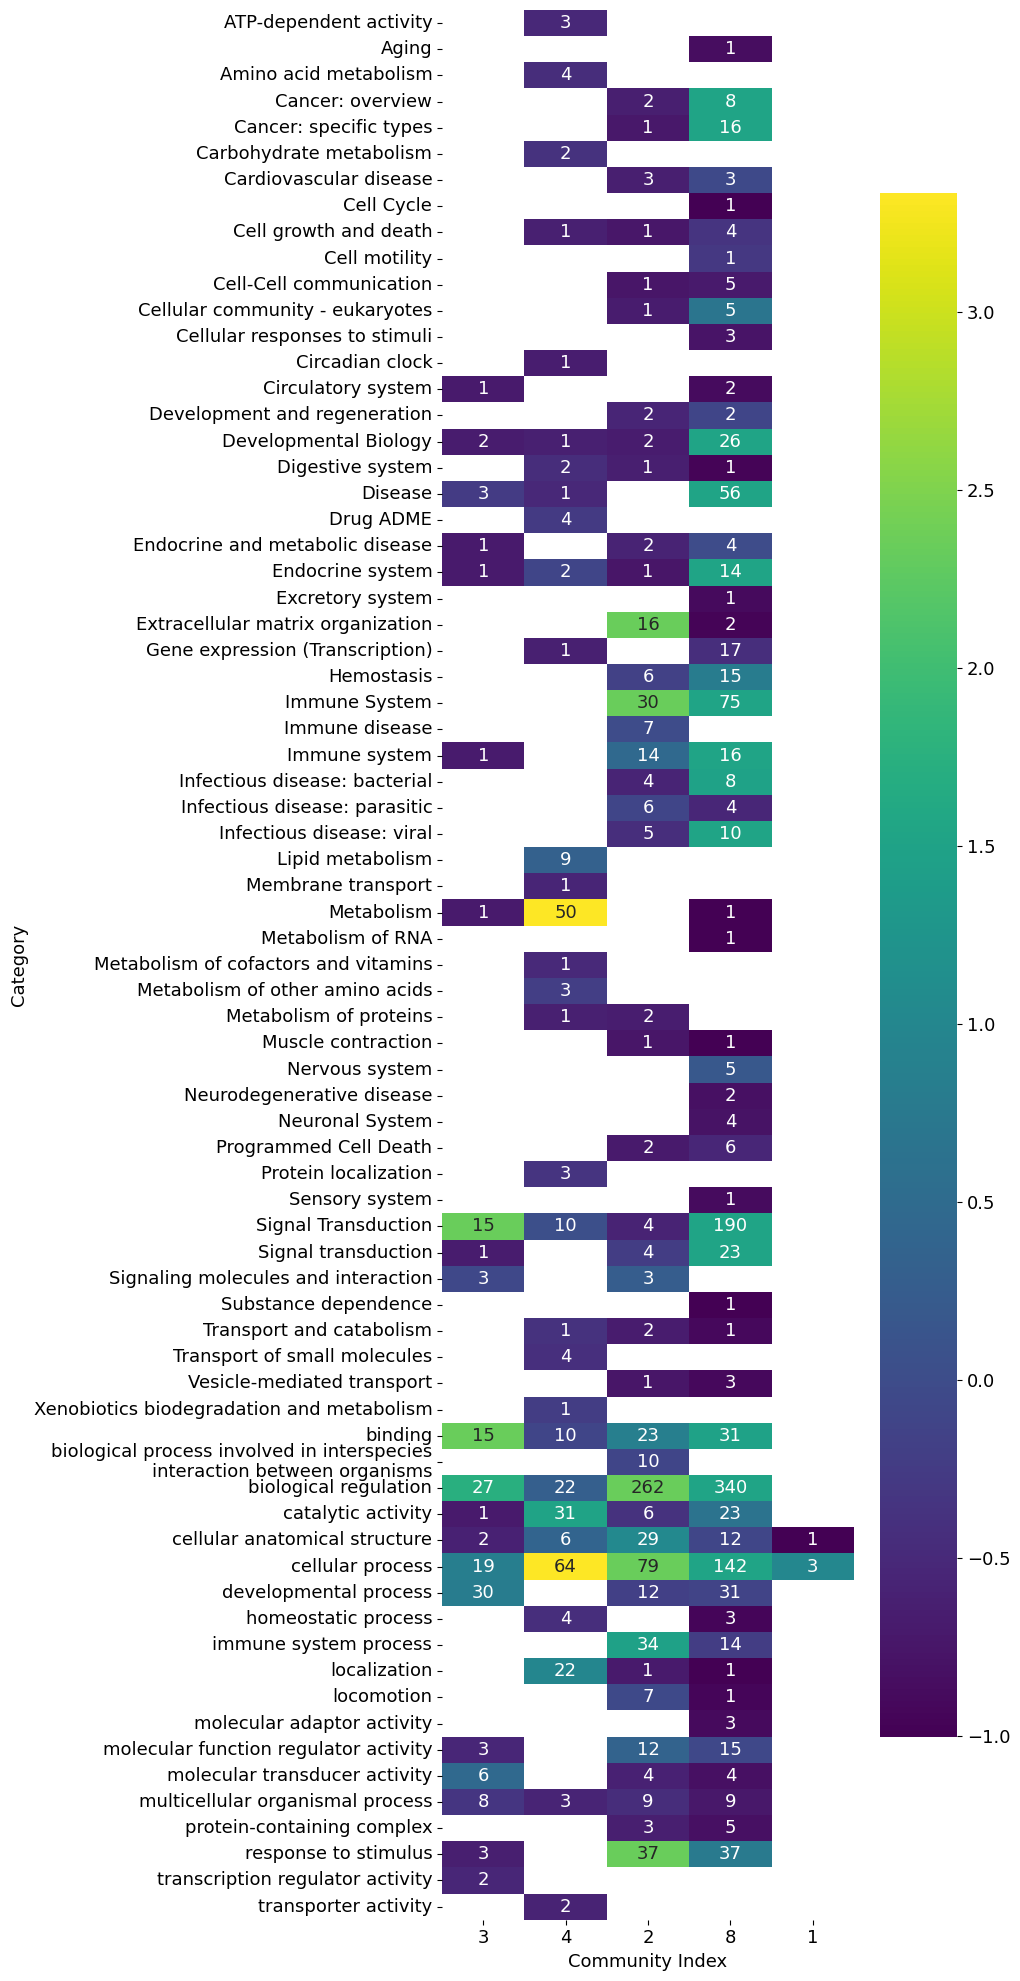

In [36]:
heat_df = community_categories_filtered.pivot(
    index="Category",
    columns="Community Index",
    values="fisher_z"
).reindex(columns = top_5_comm_indices)

label_df = community_categories_filtered.pivot(
    index="Category",
    columns="Community Index",
    values="count"
).reindex(columns = top_5_comm_indices)
plt.figure(figsize=(10,20))
ax = sns.heatmap(
    heat_df,
    cmap="viridis",
    annot=label_df,   # <-- use count for labels
    fmt=".0f",        # integer labels
    cbar=True
)

# ---- WRAP Y-AXIS LABELS ----
MAX_CHARS = 50  # tweak this
wrapped = ["\n".join(textwrap.wrap(str(s), width=MAX_CHARS)) for s in heat_df.index]
ax.set_yticklabels(wrapped, rotation=0)  # keep horizontal

plt.tight_layout()
plt.savefig(f"../../Graphs/{DISEASE}/category_gross_overlap_heatmap.png", bbox_inches="tight")
plt.show()
